<a href="https://colab.research.google.com/github/sokrypton/7.571/blob/main/pset1/empty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Set 1

**DUE DATE**
- Feb 27, 2026 11:59PM

**Instructions:**
1. Make a copy of this notebook in your Google Drive
2. Run the first code cell to download the data
3. Complete each <font color="red">TODO</font> section — replace `...` with your code
4. Download as PDF and submit to Gradescope

- File > Download > Download.ipynb
- Convert .ipynb file to PDF with [this converter](https://ovvens.com/colab-converter/)

**Collaboration:** Work together, share ideas, but write your own code and answers. List collaborators (human and/or AI) below.

**Collaborators:** <font color="red">TODO</font>

In [ ]:
# Download data files
!wget -qnc https://raw.githubusercontent.com/sokrypton/7.571/refs/heads/main/pset1/q1.csv
!wget -qnc https://raw.githubusercontent.com/sokrypton/7.571/refs/heads/main/pset1/reads_and_q_scores.csv

import numpy as np
import csv
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_ind, ttest_ind_from_stats

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---

# Problem 1: Distributions and Summary Statistics (9 points)

## Background

<a href="https://www.cellstructureatlas.org/" target="_blank">Cryo-electron tomography</a> (cryo-ET) is a powerful imaging technique that reveals the 3D structure of protein complexes inside cells. The process involves taking highly magnified images of rapidly vitrified cells and creating a 3D representation of the cellular architecture of interest.

In this study, you're analyzing the distribution of **proteasomes** (protein degradation machines) identified across 100 tomograms from each of 6 fungal species.

We will read in data from the provided .csv file using Python's built-in `csv` module and store it in a dictionary of NumPy arrays. Each key is a species name and each value is an array of proteasome counts.

In [ ]:
# Load the data (as a dictionary of numpy arrays)
with open('q1.csv') as f:
    reader = csv.reader(f)
    header = next(reader)
    columns = {name: [] for name in header}
    for row in reader:
        for name, val in zip(header, row):
            columns[name].append(float(val))

# Convert lists to numpy arrays
data = {name: np.array(vals) for name, vals in columns.items()}
species = list(data.keys())

# Preview the first 5 values for each species
for sp in species:
    print(f"{sp}: {data[sp][:5]}")

## 1a | Summary Statistics (1 point)

Calculate the **mean**, **median**, **standard deviation**, and **standard error of the mean (SEM)** for each species to the nearest whole number.

*Hint: NumPy has built-in functions for mean (`np.mean`), median (`np.median`), and std (`np.std`). SEM = std / √n*

In [ ]:
# TODO: Replace each ... with the appropriate numpy function or formula
for sp in species:
    vals = data[sp]
    mean   = ...  # np.mean()
    median = ...  # np.median()
    std    = ...  # np.std()
    sem    = ...  # std / sqrt(n)
    print(f"{sp}: mean={mean:.0f}, median={median:.0f}, std={std:.0f}, SEM={sem:.1f}")

## 1b | Visualizing Distributions (4 points)

### 1b.i | Box plots (1 point)

Visualize proteasome count distributions across all tomograms for each strain using parallel <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html" target="_blank">box-and-whisker plots</a> with matplotlib. We have provided example code showing how to plot a boxplot for two species below; modify as necessary to include all strains. *(Hint: consider how iterating over the `species` list with a for loop might simplify the code)*

In [ ]:
# Example: boxplots for 2 species
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)
ax = plt.boxplot(data['C. albicans'], positions=[0], vert=False, tick_labels=['C. albicans'])
ax = plt.boxplot(data['S. cerevisiae'], positions=[1], vert=False, tick_labels=['S. cerevisiae'])
plt.xlabel('Number of proteasomes per tomogram')
plt.title('Proteasome counts in fungal species')
plt.show()

In [ ]:
# TODO: Modify the code above to include all 6 species


### 1b.ii | Interpreting box plots (1 point)

**Question:** For each box-and-whisker plot, how much of the data does the box describe? What is the line inside the box, and when might it not be centered?

<font color="red">TODO: Your answer</font>

### 1b.iii | Outlier detection (2 points)

From the box-and-whisker plot, you notice an outlier in the number of proteasomes identified in one tomogram of *S. pombe*.

You wonder whether that outlier represents a region of increased proteasome localization. With the null hypothesis that the number of proteasomes in the outlier tomogram is sampled from the same population as the rest of those collected for *S. pombe*, calculate the **Z-score** for this outlier:

$$Z = \frac{x - \mu}{\sigma}$$

where $x$ is the outlier value, $\mu$ is the mean, and $\sigma$ is the standard deviation.

In [ ]:
# TODO: Calculate the Z-score for the S. pombe outlier
spombe  = data['S. pombe']
outlier = np.max(spombe)
mean    = np.mean(spombe)
std     = np.std(spombe)

z_score = ...  # apply the Z-score formula

print(f"Outlier value: {outlier:.0f}")
print(f"Mean: {mean:.1f}, Std: {std:.1f}")
print(f"Z-score: {z_score:.2f}")

What does the Z-score indicate? Given this Z-score (and your assumptions about the underlying population), is this outlier tomogram likely to have been sampled from the same population as the rest of those measured? Calculate the **p-value** using a one-tailed test to determine whether this result is significant.

*Hint: `norm.cdf(z)` gives the probability of observing a value ≤ z standard deviations from the mean.*

In [ ]:
# TODO: Calculate the p-value
p_value = 1 - norm.cdf(...)  # what goes here?

print(f"P-value: {p_value:.2e}")

<font color="red">TODO: Interpret the Z-score and p-value. Is this outlier likely from the same population?</font>

## 1c | Cumulative Distribution Functions (3 points)

### 1c.i | Plot CDFs (2 points)

A **cumulative distribution function (CDF)** shows the fraction of data ≤ each value. Use the provided `compute_cdf` function to generate a figure showing the CDF of all six species on one graph.

In [ ]:
def compute_cdf(values):
    """Compute CDF for a 1D array. Returns sorted x values and cumulative probabilities."""
    x_sorted = np.sort(values)
    y_cdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y_cdf

# TODO: Fill in the loop body to plot each species' CDF
plt.figure(figsize=(10, 6))

for sp in species:
    x, y = ...  # use compute_cdf
    plt.plot(...)  # plot with label=sp

plt.xlabel('Number of proteasomes per tomogram')
plt.ylabel('CDF')
plt.legend()
plt.title('CDFs of Proteasome Counts')
plt.show()

### 1c.ii | Interpret the CDFs (1 point)

**Question:** What does the y-axis of the CDF plot indicate? Which species has the highest proteasome counts, and how can you tell from the CDF?

<font color="red">TODO: Your answer</font>

---

# Problem 2: Poisson Statistics in DNA Sequencing (8 points)

## Background

Today the majority of high-throughput DNA sequencing is based on short-read (50-150 bases) platforms developed by the company Illumina. Several alternate approaches provide much longer sequencing lengths (>10 kilobases), which are advantageous when studying repetitive DNA sequences or alternative RNA splicing isoforms. One of these long-read sequencers is pioneered by **Pacific Biosciences (PacBio)**.

PacBio's technology works by watching single DNA polymerases incorporate fluorescent nucleotides in real-time. The key technology is the **zero-mode waveguide (ZMW)** — a tiny well (~100nm diameter) that can observe single molecules.

For a helpful visualization: <a href="https://youtu.be/7yYPHatccgw" target="_blank">PacBio SMRT Sequencing Video</a>

PacBio pre-loads stalled phi29 DNA polymerase onto the DNA to be sequenced and then applies a solution of these polymerase-DNA complexes to the ZMW array. Once bound to the bottom of the wells, they activate the polymerases in the presence of fluorescently labelled dNTPs, which are incorporated in the newly synthesized strand, and recording the pattern of fluorescence yields the DNA sequence. A simplified diagram of a ZMW is shown below.

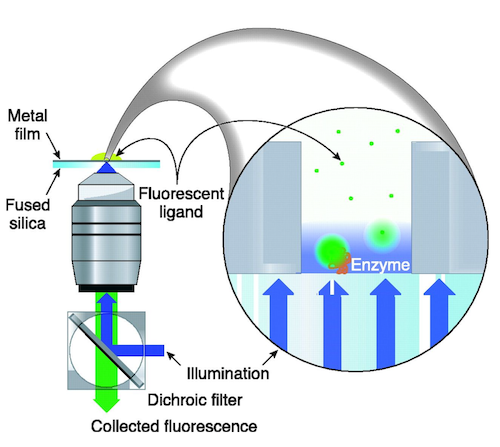

## 2a | Why Binomial? (1 point)

To set up a sequencing run, an array of ZMWs is immersed in a dilute solution of DNAs complexed with the polymerase. During an incubation period, DNA molecules diffuse and stick to the bottom of ZMWs.

**Question:** Explain why the probability distribution for the number of DNA molecules ($k$) loaded per ZMW follows a Binomial distribution:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

What do *n* and *p* correspond to in this context?

<font color="red">TODO: Your answer</font>

## 2b | Why keep np small? (1 point)

The concentration of DNA and the length of incubation period determine *n* and *p*.

**Question:** Explain why it is beneficial to use a concentration and incubation time such that the product of *n* and *p*, i.e., *n* times *p*, is not substantially greater than one.

<font color="red">TODO: Your answer</font>

## 2c | Why Poisson? (1 point)

**Question:** Based on the descriptions in 2a and 2b, explain why the number of DNA molecules per ZMW approximately follows the Poisson distribution.

<font color="red">TODO: Your answer</font>

## 2d | Optimizing DNA Loading (3 points)

Due to the stochastic nature of DNA loading, not all ZMWs in the array will produce sequencing results. Some will contain no DNAs, whereas some will have too many. In fact, only the ZMWs that have exactly one DNA molecule can provide useful information. To optimize the fraction of ZMWs with one DNA molecule, you need to find the mean number of DNA molecules per well ($c = np$) that maximizes $P(X = 1)$.

### 2d.i | Plot P(1) vs c (1 point)

When $n$ is large and $p$ is small, the Binomial approaches the **Poisson distribution**:

$$P(X = k) = \frac{c^k e^{-c}}{k!}$$

where $c = np$ is the mean number of DNA molecules per ZMW.

Implement the function below and the plot will be generated for you.

In [ ]:
def prob_one_dna(c):
    """
    Calculate P(X=1) for Poisson with mean c.

    Input:
        c: mean number of DNA molecules per ZMW across the array (c = np).
    Output:
        Probability that any one ZMW receives exactly one DNA molecule.

    Recall: P(X=k) = c^k * e^(-c) / k!   where k=1
    """
    # TODO: implement the Poisson formula for k=1
    return ...

# --- Plotting code (no changes needed below) ---
c_values = np.arange(0, 10, 0.01)
y = prob_one_dna(c_values)

fig = plt.figure(figsize=(12, 6))
plt.plot(c_values, y, 'r', linewidth=2)
plt.xticks(np.arange(0, 11))
plt.xlim([0, 10])
plt.grid()

# TODO: Label the axes appropriately
plt.xlabel('TODO')
plt.ylabel('TODO')

plt.show()

### 2d.ii | Optimal loading (1 point)

**Question:** Using the plot you have generated, find the value of $c$ that optimizes $P(1)$.

<font color="red">TODO: Your answer</font>

### 2d.iii | Expected throughput (1 point)

**Question:** For an array that contains 1.5 million ZMWs, what is the expected throughput (i.e. mean number of sequencing reads per run) that can be achieved if you use the value of $c$ that maximizes $P(1)$? Show your work.

<font color="red">TODO: Your answer (show calculation)</font>

## 2e | When Poisson Fails (2 points)

Once you've optimized for single DNA molecules per ZMW across the array, you now add fluorescent methyltransferases to study DNA methylation. You observe all wells where binding events occur. However, you find that most DNA molecules have **0 or 2** methyltransferases bound, but very few have **1**.

**Question:** This doesn't follow Poisson statistics. What assumption of the Poisson distribution is violated, and what does this tell you biologically?

<font color="red">TODO: Your answer</font>

---

# Problem 3: Statistical Significance and Power (10 points)

> **Reminder:**
>
> **Power** = P(detecting an effect when it truly exists) = 1 - β
>
> | | H₀ True (no effect) | H₀ False (real effect) |
> |--|---------------------|------------------------|
> | **Reject H₀** | Type I Error (α) | ✓ Correct (Power) |
> | **Fail to reject** | ✓ Correct | Type II Error (β) |
>
> **Power depends on:**
> - **α** (significance threshold): lower α → lower power
> - **Sample size (n)**: more samples → higher power  
> - **Effect size**: larger effects are easier to detect
> - **Variance**: less noise → higher power

## Background

A researcher is interested in studying how phosphorylation at a given site affects the ability of their protein of interest (Protein L) to bind to its interaction partner (Protein IP). Using 100 µL reactions and 1 mM protein, the researcher measured the amount of the interaction partner that binds to wildtype Protein L ($L_{wt}$) as well as to phosphomimetic L ($L_{phos}$). In this experiment, the amount of interaction partner that bound was quantified using its fluorescence intensity (arbitrary units). The data is summarized below:

In [ ]:
# Experimental data
experiment = {
    'L_wt':   {'mean': 5723, 'std': 1794, 'n': 6},
    'L_phos': {'mean': 3957, 'std': 1531, 'n': 6}
}

# Display
print(f"{'Condition':<12} {'Mean':>8} {'Std':>8} {'N':>4}")
print("-" * 36)
for cond, vals in experiment.items():
    print(f"{cond:<12} {vals['mean']:>8} {vals['std']:>8} {vals['n']:>4}")

## 3a | State the Hypotheses (0.5 points)

The researcher reported that they used a two-tailed t-test to determine whether the phosphorylation of Protein L has an effect on binding to its interaction partner.

**Question:** What are the null and alternative hypotheses in this statistical test?

<font color="red">TODO: Your answer</font>

## 3b | Perform the Test (1 point)

Perform a two-tailed t-test with $\alpha=0.05$ to determine whether the researcher is able to reject the null hypothesis based on the data they have collected. What can the researcher conclude?

*Hint: use `ttest_ind_from_stats(mean1, std1, nobs1, mean2, std2, nobs2)` from scipy.stats*

In [ ]:
# TODO: Fill in the values from the experiment data
t_stat, p_value = ttest_ind_from_stats(
    mean1=..., std1=..., nobs1=...,
    mean2=..., std2=..., nobs2=...
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

**Question:** Can the researcher reject the null hypothesis? What's the conclusion?

<font color="red">TODO: Your answer</font>

## 3c | Assumptions of the Test (1 point)

**Question:** What are the assumptions of the statistical model used in this hypothesis test?

<font color="red">TODO: Your answer</font>

## 3d | Alpha and Errors (1 point)

**Question:** In general, what does an alpha cutoff of 0.05 indicate, what error is this describing, and what does it tell us? How would decreasing the alpha cutoff change the probability of a Type II error?

<font color="red">TODO: Your answer</font>

## 3e | Power Analysis by Simulation (5 points)

You're thinking about trying a similar experiment, but you suspect that for your protein, phosphorylation only changes binding by a small amount and you're worried that you won't be able to detect the difference using this researcher's methods.

Given that the researcher performed only 6 replicate measurements with each protein and set the significance threshold at 0.05, you would like to know the range of effect sizes for which this experimental design provides sufficient statistical power.

**Effect size** = $\log_2(\mu_{phos} / \mu_{wt})$

For each round of the simulation, we will keep $\mu_{wt}$ constant at 5,723 and vary $\mu_{phos}$, starting from 8-fold lower than $\mu_{wt}$, and increasing to 8-fold higher than $\mu_{wt}$.

We will assume that population standard deviations are always one-third of the mean ($\sigma_{wt} = \mu_{wt}/3$ and $\sigma_{phos} = \mu_{phos}/3$).

At each effect size, perform 1000 simulated experiments (each drawing 6 replicates per group), run a t-test, and calculate the fraction of simulations that yield $p < 0.05$. This fraction is the estimated **power** at that effect size.

We provide the `simulate_experiment` function below. Your task is to use it to calculate power across a range of effect sizes.

In [ ]:
# This function is provided for you — read it to understand what it does
def simulate_experiment(mu1, sigma1, mu2, sigma2, n, num_sims=1000, alpha=0.05):
    """
    Simulate experiments and return the fraction with p < alpha (i.e., power).

    Parameters:
        mu1, sigma1: mean and std of group 1
        mu2, sigma2: mean and std of group 2
        n: sample size per group
        num_sims: number of simulations
        alpha: significance threshold

    Returns:
        power: fraction of simulations detecting the effect
    """
    significant = 0
    for _ in range(num_sims):
        sample1 = np.random.normal(mu1, sigma1, n)
        sample2 = np.random.normal(mu2, sigma2, n)
        _, p_value = ttest_ind(sample1, sample2)
        if p_value < alpha:
            significant += 1
    return significant / num_sims

In [ ]:
# TODO: Calculate power across a range of effect sizes
# Replace each ... with the correct expression

effect_sizes = np.linspace(-3, 3, 25)
wt_mu = 5723
power = []

for es in effect_sizes:
    phos_mu    = ...  # wt_mu * 2^(effect_size)
    wt_sigma   = ...  # mu / 3
    phos_sigma = ...  # mu / 3

    pwr = simulate_experiment(..., ..., ..., ..., n=6)
    power.append(pwr)

Plot the relationship between effect size and power below. Use `plt.plot` for the data and `plt.axhline` for the 0.9 power line (important for 3f).

In [ ]:
# --- Plotting code ---
fig = plt.figure(figsize=(12, 6))
plt.grid()

# TODO: Plot power vs effect size and add the 90% power line
plt.plot(...)       # your data
plt.axhline(...)    # 90% power line

# Axis formatting (no changes needed)
plt.xticks(np.arange(-2.5, 3, step=0.5))
plt.xlim(-3, 3)

# TODO: Label the axes
plt.xlabel('TODO')
plt.ylabel('TODO')

plt.grid()
plt.show()

## 3f | Minimum Detectable Effect (0.5 points)

**Question:** Estimating from the graph, what are the smallest effect sizes (fold-change higher or lower) that the experiment would have a 90% chance of detecting?

<font color="red">TODO: Your answer</font>

## 3g | One-tailed vs Two-tailed (1 point)

When presenting this data in group meeting, a colleague suggests reframing the hypothesis to test that binding of the interaction partner to $L_{phos}$ is *decreased* relative to $L_{wt}$.

**Question:** Report the p-value using a one-tailed t-test. Is this suggestion reasonable? Note that the researcher had no prior assumption that the binding would decrease in the phosphomimetic.

*Hint: `ttest_ind_from_stats` accepts an `alternative` parameter ('two-sided', 'less', 'greater'). Alternatively, for a one-tailed test you can divide the two-tailed p-value by 2.*

In [ ]:
# TODO: Calculate the one-tailed p-value
t_stat, p_one_tailed = ttest_ind_from_stats(
    mean1=5723, std1=1794, nobs1=6,
    mean2=3957, std2=1531, nobs2=6,
    alternative=...  # which alternative?
)

print(f"One-tailed p-value: {p_one_tailed:.4f}")

<font color="red">TODO: Is this suggestion reasonable? Why or why not?</font>

---

# Problem 4: Bayes' Theorem (8 points)

## Refresher
Recall that Bayes' Law is a way of defining the *conditional probability* of an event.

For example, we could ask, what is the probability that it rains given that it is cloudy. In other words, what is **P(rain | cloudy)**?

Using Bayes' Law we can calculate this probability as follows:

**P(rain | cloudy)** = $\frac{P(\text{cloudy} | \text{rain}) \cdot P(\text{rain})}{P(\text{cloudy})}$

And we can further break-down the denominator by *marginalizing* over the possible weather conditions:

$P(\text{rain | cloudy}) = \frac{P(\text{cloudy | rain}) \cdot P(\text{rain})}{P(\text{cloudy | rain}) \cdot P(\text{rain}) + P(\text{cloudy | no rain}) \cdot P(\text{no rain})}$

## The Problem

With that brief refresher, let's explore Bayes' Theorem in the context of a biological example.

You're a cancer researcher and you've just performed a next-generation sequencing experiment, which allows you to sequence individual molecules of DNA in a population. The goal of the experiment is to detect a particular cancer-associated mutation from these sequencing reads so as to determine the fraction of individuals in your population that carry the mutation. However, next-generation sequencing reads are not always correct — each read has a certain probability of containing a sequencing error. So, given your observation of a mutation in a read, you need to determine the probability that it represents a true mutation and not a sequencing error.

## 4a | Set Up Bayes' Rule (2 points)

We want: $P(\text{Mutation} | \text{Detected})$

### 4a.i | Basic form (1 point)

**Question:** First, state the problem in mathematical terms (i.e. an equation) by replacing the dummy variables below with the appropriate terms.

<font color="red">TODO: Replace A and B below</font>

**Un-marginalized equation:**

$P(\text{A} | \text{B}) = \frac{P(\text{B}|\text{A}) \cdot P(\text{A})}{P(\text{B})}$

### 4a.ii | Expanded form (1 point)

**Question:** Now write the equation with the denominator marginalized by replacing the dummy variables.

*Hint: Detection can happen if (mutation AND correctly read) OR (no mutation AND incorrectly read)*

<font color="red">TODO: Replace the dummy variables below</font>

**Marginalized equation:**

$P(\text{A} | \text{B}) = \frac{P(\text{B}|\text{A}) \cdot P(\text{A})}{P(\text{B}|\text{x1}) \cdot P(\text{x1}) + P(\text{B}|\text{x2}) \cdot P(\text{x2})}$

## 4b | Apply to Real Data (5 points)

Now that we have the problem stated in mathematical terms, let's deal with the actual data. The provided .csv file (**'reads_and_q_scores.csv'**) contains 2 columns: "reads" and "Q_score". The "reads" column corresponds to the raw sequencing read and the "Q_score" is the quality score for that read.

The **Q score** corresponds with the accuracy of the sequencing read such that:

$Q = -10\log_{10}(P(\text{incorrect sequencing read}))$

Higher Q scores mean a lower probability of error:

| Q Score | P(error) | Accuracy |
|---------|----------|----------|
| 10 | 0.1 | 90% |
| 20 | 0.01 | 99% |
| 30 | 0.001 | 99.9% |
| 40 | 0.0001 | 99.99% |

### 4b.i | Classify reads (1 point)

Read the .csv file and classify each read as wildtype or mutant by comparing to the reference sequences.

In [ ]:
# Load the sequencing data
with open('reads_and_q_scores.csv') as f:
    reader = csv.DictReader(f)
    reads = []
    q_scores = []
    for row in reader:
        reads.append(row['reads'])
        q_scores.append(float(row['Q_score']))

reads = np.array(reads)
q_scores = np.array(q_scores)

# Reference sequences
wildtype = 'AATAGGATTACCATGACATACGGGCTACGACATAC'
mutant   = 'AATAGGATTACCATGAAATACGGGCTACGACATAC'  # C>A at position 16

print(f"Total reads: {len(reads)}")

In [ ]:
# TODO: Classify each read by comparing to the reference sequences
classifications = []
for read in reads:
    if read == ...:        # compare to wildtype
        classifications.append('WT')
    elif read == ...:      # compare to mutant
        classifications.append('Mutant')
    else:
        classifications.append('Unknown')

classifications = np.array(classifications)

# Filter to mutant reads only
mutant_mask = (classifications == 'Mutant')
mutant_q_scores = q_scores[mutant_mask]

print(f"WT: {np.sum(classifications == 'WT')}")
print(f"Mutant: {np.sum(mutant_mask)}")

### 4b.ii | Calculate posterior probabilities (3 points)

For each mutant read, calculate the probability that it is a true mutation (i.e. not a false positive) based on the Q score of that read. Assume that your prior estimate of the mutation frequency is 0.6.

In [ ]:
def q_to_error_prob(q):
    """Convert Q score to error probability: P(error) = 10^(-Q/10)"""
    return 10 ** (-q / 10)

def calc_posterior(q_score, prior_mutation=0.6):
    """
    Calculate P(true mutation | detected mutation) using Bayes' rule.

    Parameters:
        q_score: quality score of the read
        prior_mutation: prior probability the sample has the mutation
    Returns:
        posterior: P(mutation | detected)
    """
    error_prob   = q_to_error_prob(q_score)
    correct_prob = 1 - error_prob

    # TODO: Fill in each term using error_prob, correct_prob, and prior_mutation
    p_det_given_mut    = ...  # P(detected | mutation) — is this correct_prob or error_prob?
    p_det_given_no_mut = ...  # P(detected | no mutation)
    p_mut              = ...  # P(mutation)
    p_no_mut           = ...  # P(no mutation)

    # TODO: Apply Bayes' rule
    numerator   = ...
    denominator = ...

    return numerator / denominator

# Calculate posterior for each mutant read
posteriors = np.array([calc_posterior(q) for q in mutant_q_scores])

# Show a few results
print("Sample results:")
for i in range(min(5, len(mutant_q_scores))):
    print(f"  Q={mutant_q_scores[i]:.1f} -> P(true mutation)={posteriors[i]:.4f}")

### 4b.iii | Visualize the relationship (1 point)

Make a simple plot to show the relationship between Q-score (x-axis) and the probability an observed mutation is a true positive (y-axis).

In [ ]:
# Plotting code provided — no changes needed
plt.figure(figsize=(10, 6))
plt.scatter(mutant_q_scores, posteriors, alpha=0.5, s=30)
plt.xlabel('Q Score')
plt.ylabel('P(true mutation | detected)')
plt.title('Confidence in Mutation vs Read Quality')
plt.grid(True, alpha=0.3)
plt.show()

## 4c | Effect of Prior (1 point)

**Question:** How would the probability of a mutation being a true positive change if our prior estimate of the mutation frequency decreased (e.g., from 0.6 to 0.1)? Respond briefly in 1-2 sentences.

<font color="red">TODO: Your answer</font>

---

# Submission Checklist

- [ ] All TODO sections completed (no `...` remaining)
- [ ] All code cells executed
- [ ] Collaborators listed
- [ ] Downloaded as PDF
- [ ] Submitted to Gradescope